In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("https://raw.githubusercontent.com/Premalatha-success/Datasets/refs/heads/main/Churn_Modelling.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
### Exited -> o/p column
### Exited-> 1 ,0-> no
### Classification

In [4]:
df.describe(include="all")

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


array([[<Axes: title={'center': 'RowNumber'}>,
        <Axes: title={'center': 'CustomerId'}>,
        <Axes: title={'center': 'CreditScore'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Tenure'}>,
        <Axes: title={'center': 'Balance'}>],
       [<Axes: title={'center': 'NumOfProducts'}>,
        <Axes: title={'center': 'HasCrCard'}>,
        <Axes: title={'center': 'IsActiveMember'}>],
       [<Axes: title={'center': 'EstimatedSalary'}>,
        <Axes: title={'center': 'Exited'}>, <Axes: >]], dtype=object)

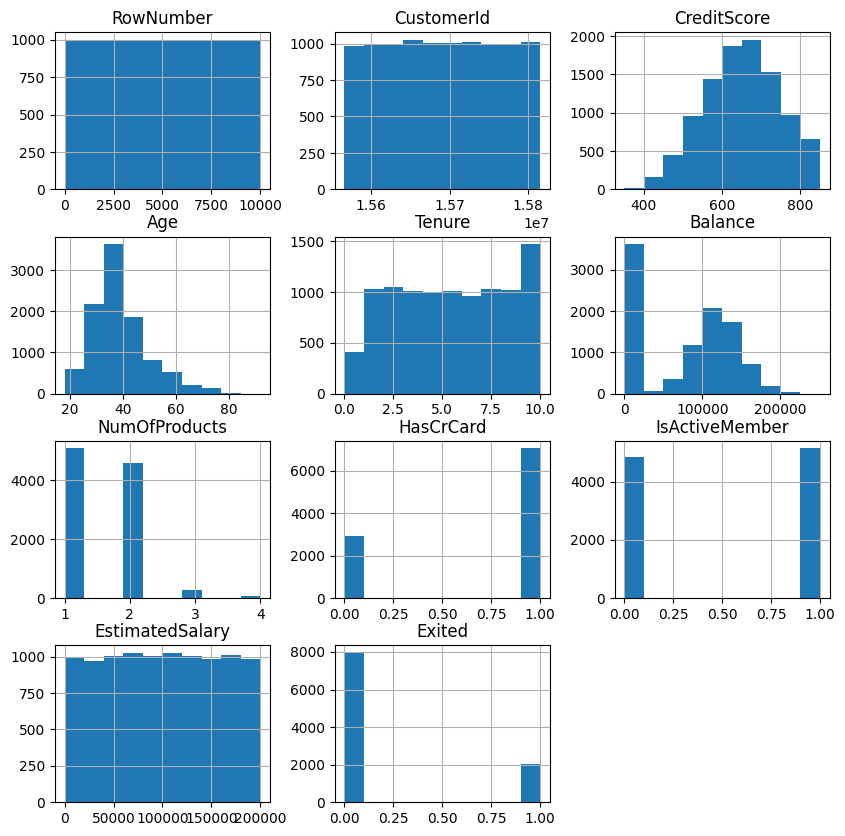

In [5]:
df.hist(figsize=(10,10))

In [ ]:
### exited 0-> 8000
#### exited 1 -> 2000

In [ ]:
### Identify the insignificant columns
### Customerid,surname,Rownumber

In [6]:
df=df.drop(["RowNumber","CustomerId","Surname"],axis=1)

In [7]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.shape

(10000, 11)

In [9]:
df=pd.get_dummies(df,columns=["Gender","Geography"])

In [11]:
df.sample(10)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Spain
1509,528,37,6,103772.45,1,1,0,197111.99,0,False,True,True,False,False
4097,597,26,7,0.00,2,1,0,110253.20,0,True,False,False,False,True
313,806,59,0,135296.33,1,1,0,182822.50,0,True,False,False,True,False
5169,651,31,7,138008.06,2,1,0,129912.74,0,False,True,False,True,False
9105,658,31,5,100082.14,1,0,1,49809.88,0,False,True,True,False,False
5554,620,38,0,0.00,2,1,1,38015.34,0,False,True,False,False,True
3855,708,32,3,151691.44,2,1,1,172810.51,0,False,True,False,True,False
9815,604,34,7,0.00,2,1,1,188078.55,0,False,True,True,False,False
2672,724,34,2,154485.74,2,0,0,78560.64,0,False,True,True,False,False
2469,727,36,6,140418.81,1,1,1,113033.73,1,False,True,False,True,False


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [13]:
Y=df[["Exited"]]
X=df.drop(["Exited"],axis=1)

In [14]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.30)

In [15]:
import warnings
warnings.filterwarnings("ignore")

In [16]:
model_lr=LogisticRegression()
model_lr.fit(X_train,Y_train)

LogisticRegression()

In [17]:
model_lr.score(X_train,Y_train)

0.7925714285714286

In [18]:
model_lr.score(X_test,Y_test)

0.7883333333333333

In [23]:
from sklearn.neighbors import KNeighborsClassifier
model_knn=KNeighborsClassifier(n_neighbors=23)
model_knn.fit(X_train,Y_train)
print(model_knn.score(X_train,Y_train))
print(model_knn.score(X_test,Y_test))

0.7968571428571428
0.7956666666666666


In [24]:
from sklearn.svm import SVC
model_svc=SVC()
model_svc.fit(X_train,Y_train)
print(model_svc.score(X_train,Y_train))
print(model_svc.score(X_test,Y_test))

0.7968571428571428
0.795


In [35]:
from sklearn.tree import DecisionTreeClassifier
model_dt=DecisionTreeClassifier(max_depth=4)
model_dt.fit(X_train,Y_train)
print(model_dt.score(X_train,Y_train))
print(model_dt.score(X_test,Y_test))

0.8552857142857143
0.8503333333333334


In [41]:
from sklearn.ensemble import BaggingClassifier
model_bg=BaggingClassifier(n_estimators=10,max_samples=0.05)
model_bg.fit(X_train,Y_train)
print(model_bg.score(X_train,Y_train))
print(model_bg.score(X_test,Y_test))

0.8618571428571429
0.8476666666666667


In [ ]:
### Which model should be deployed

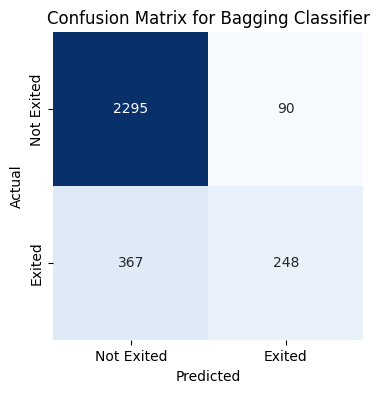

In [43]:
from sklearn.metrics import confusion_matrix
Y_pred_bg = model_bg.predict(X_test)
cm_bg = confusion_matrix(Y_test, Y_pred_bg)

plt.figure(figsize=(4, 4))
sns.heatmap(cm_bg, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Exited', 'Exited'], yticklabels=['Not Exited', 'Exited'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Bagging Classifier')
plt.show()

In [44]:
2295+90+367+248

3000

In [ ]:
### Exited -> P

In [45]:
TP=248
TN=2295
FP=90
FN=367

In [46]:
acc=(TP+TN)/(TP+TN+FP+FN)
acc

0.8476666666666667

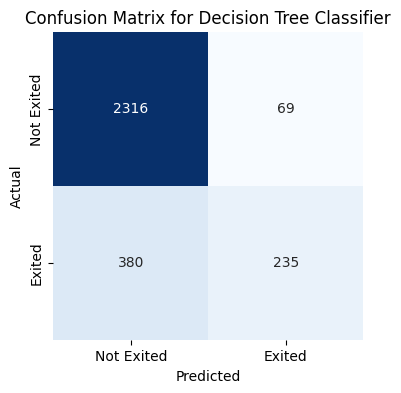

In [48]:
from sklearn.metrics import confusion_matrix
Y_pred_dt = model_dt.predict(X_test)
cm_dt = confusion_matrix(Y_test, Y_pred_dt)

plt.figure(figsize=(4,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Exited', 'Exited'], yticklabels=['Not Exited', 'Exited'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.show()

# Task
Install Gradio, then create a web interface using Gradio to deploy the trained `model_dt` (Decision Tree Classifier) that predicts customer churn. The interface should take `CreditScore`, `Age`, `Tenure`, `Balance`, `NumOfProducts`, `HasCrCard`, `IsActiveMember`, `EstimatedSalary`, `Gender`, and `Geography` as inputs, preprocess them correctly (including one-hot encoding for 'Gender' and 'Geography'), and display the predicted 'Exited' status.

## Install Gradio

### Subtask:
Install the Gradio library to create the web interface for the model.


**Reasoning**:
The subtask requires installing the Gradio library. The `!pip install gradio` command will install the necessary package.



In [49]:
pip install gradio

## Define Prediction Function

### Subtask:
Create a Python function that accepts all necessary input features, performs the same preprocessing steps (like one-hot encoding for Gender and Geography) as done during training, and then uses the 'model_dt' to predict the 'Exited' status. This function will return a human-readable prediction.


**Reasoning**:
To define the prediction function, I need to create a Python function that takes the raw input features, preprocesses them to match the training data format (including one-hot encoding for categorical variables), and then uses the trained Decision Tree model (`model_dt`) to make a prediction. I will also ensure the output is human-readable.



In [50]:
import pandas as pd

def predict_churn(CreditScore, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Gender, Geography):
    # Create a DataFrame from the input features
    input_data = pd.DataFrame({
        'CreditScore': [CreditScore],
        'Age': [Age],
        'Tenure': [Tenure],
        'Balance': [Balance],
        'NumOfProducts': [NumOfProducts],
        'HasCrCard': [HasCrCard],
        'IsActiveMember': [IsActiveMember],
        'EstimatedSalary': [EstimatedSalary],
        'Gender': [Gender],
        'Geography': [Geography]
    })

    # Apply one-hot encoding for 'Gender'
    input_data['Gender_Female'] = (input_data['Gender'] == 'Female').astype(bool)
    input_data['Gender_Male'] = (input_data['Gender'] == 'Male').astype(bool)
    input_data = input_data.drop('Gender', axis=1)

    # Apply one-hot encoding for 'Geography'
    input_data['Geography_France'] = (input_data['Geography'] == 'France').astype(bool)
    input_data['Geography_Germany'] = (input_data['Geography'] == 'Germany').astype(bool)
    input_data['Geography_Spain'] = (input_data['Geography'] == 'Spain').astype(bool)
    input_data = input_data.drop('Geography', axis=1)

    # Ensure the column order matches the training data (X_train or X)
    # We need to explicitly reorder the columns to match X.columns
    # First, let's create a list of all expected columns from X
    expected_columns = list(X.columns) # X is the full feature set used for training

    # Reorder the input_data columns to match expected_columns
    # If any column is missing from input_data (e.g., if a geography wasn't present in initial inputs),
    # it will be added with False values.
    for col in expected_columns:
        if col not in input_data.columns:
            input_data[col] = False
    input_data = input_data[expected_columns]

    # Make prediction using the trained model
    prediction = model_dt.predict(input_data)

    # Convert numerical prediction to human-readable string
    if prediction[0] == 1:
        return 'Customer will churn'
    else:
        return 'Customer will not churn'

print("Prediction function 'predict_churn' defined.")

Prediction function 'predict_churn' defined.


**Reasoning**:
Now that the prediction function `predict_churn` is defined and available, the next step is to create the Gradio interface. This involves importing the `gradio` library and setting up the interface components (inputs and outputs) using the `predict_churn` function as the core prediction logic, which directly addresses the main task.



In [51]:
import gradio as gr

# Define the Gradio interface
# Inputs should match the arguments of the predict_churn function
inputs = [
    gr.Slider(minimum=350, maximum=850, step=1, default=650, label='CreditScore'),
    gr.Slider(minimum=18, maximum=92, step=1, default=35, label='Age'),
    gr.Slider(minimum=0, maximum=10, step=1, default=5, label='Tenure'),
    gr.Number(default=50000.0, label='Balance'),
    gr.Slider(minimum=1, maximum=4, step=1, default=1, label='NumOfProducts'),
    gr.Radio(choices=[0, 1], default=1, label='HasCrCard (0=No, 1=Yes)'),
    gr.Radio(choices=[0, 1], default=1, label='IsActiveMember (0=No, 1=Yes)'),
    gr.Number(default=100000.0, label='EstimatedSalary'),
    gr.Radio(choices=['Female', 'Male'], default='Female', label='Gender'),
    gr.Radio(choices=['France', 'Germany', 'Spain'], default='France', label='Geography')
]

# Output is a text box for the prediction result
output = gr.Textbox(label='Churn Prediction')

# Create the Gradio interface
interface = gr.Interface(
    fn=predict_churn,
    inputs=inputs,
    outputs=output,
    title='Customer Churn Prediction',
    description='Enter customer details to predict if they will churn.'
)

# Launch the interface
interface.launch(inline=True)
print("Gradio interface launched.")

TypeError: Slider.__init__() got an unexpected keyword argument 'default'

**Reasoning**:
The error `TypeError: Slider.__init__() got an unexpected keyword argument 'default'` indicates that the `default` parameter is not valid for `gr.Slider` in the current Gradio version. I need to replace `default` with `value` for all `gr.Slider`, `gr.Number`, and `gr.Radio` components to correctly set their initial values.



In [52]:
import gradio as gr

# Define the Gradio interface
# Inputs should match the arguments of the predict_churn function
inputs = [
    gr.Slider(minimum=350, maximum=850, step=1, value=650, label='CreditScore'),
    gr.Slider(minimum=18, maximum=92, step=1, value=35, label='Age'),
    gr.Slider(minimum=0, maximum=10, step=1, value=5, label='Tenure'),
    gr.Number(value=50000.0, label='Balance'),
    gr.Slider(minimum=1, maximum=4, step=1, value=1, label='NumOfProducts'),
    gr.Radio(choices=[0, 1], value=1, label='HasCrCard (0=No, 1=Yes)'),
    gr.Radio(choices=[0, 1], value=1, label='IsActiveMember (0=No, 1=Yes)'),
    gr.Number(value=100000.0, label='EstimatedSalary'),
    gr.Radio(choices=['Female', 'Male'], value='Female', label='Gender'),
    gr.Radio(choices=['France', 'Germany', 'Spain'], value='France', label='Geography')
]

# Output is a text box for the prediction result
output = gr.Textbox(label='Churn Prediction')

# Create the Gradio interface
interface = gr.Interface(
    fn=predict_churn,
    inputs=inputs,
    outputs=output,
    title='Customer Churn Prediction',
    description='Enter customer details to predict if they will churn.'
)

# Launch the interface
interface.launch(inline=True)
print("Gradio interface launched.")

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0437b039a06fa98812.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Gradio interface launched.


## Summary:

### Data Analysis Key Findings
*   Gradio, version 5.50.0, was already installed in the environment, satisfying the installation requirement.
*   A Python function `predict_churn` was successfully defined to preprocess input features (including one-hot encoding for 'Gender' and 'Geography') and predict customer churn using the `model_dt`.
*   An initial attempt to launch the Gradio interface resulted in a `TypeError` due to the use of the `default` parameter for setting initial values in Gradio components.
*   The `TypeError` was resolved by replacing `default` with `value` in all `gr.Slider`, `gr.Number`, and `gr.Radio` components, leading to a successful launch of the Gradio interface.

### Insights or Next Steps
*   The deployed Gradio interface provides an accessible way for users to interact with the churn prediction model.
*   Consider enhancing the Gradio interface with error handling for invalid user inputs or adding model interpretability features (e.g., displaying feature importance).


In [ ]:
### income -> negative
### Age

### DS -> min,max

10000 -> (1000) -> aside

9000-> 70% train ,30% test